## Checagem de sanidade dos dados tratados

### 1. Consistência entre colunas

In [35]:
import pandas as pd

df1 = pd.read_parquet('../data/processed/glp-2023-01-processed')
df2 = pd.read_parquet('../data/processed/glp-2023-02-processed')
df3 = pd.read_parquet('../data/processed/glp-2024-01-processed')
df4 = pd.read_parquet('../data/processed/glp-2024-02-processed')
df5 = pd.read_parquet('../data/processed/glp-2025-01-processed')
df6 = pd.read_parquet('../data/processed/glp-2025-02-processed')



In [36]:
def comparar_colunas(dframe1, dframe2):
    return dframe1.columns.equals(dframe2.columns)
    
frames = [df2,df3,df4,df5,df6]
for df in frames:
    resultado = comparar_colunas(df1, df)
    print(resultado)

True
True
True
True
True


Resultado: datasets possuem uma mesma estrutura, portanto podem ser combinados

### 2. Volume dos arquivos

In [37]:
num_linhas = []
frames = [df1,df2,df3,df4,df5,df6]
for df in frames:
    num_linhas.append(df['Regiao - Sigla'].count())

num_linhas

[np.int64(105341),
 np.int64(121725),
 np.int64(122071),
 np.int64(38425),
 np.int64(71780),
 np.int64(53423)]

Insight: A partir do segundo semestre de 2024, o número de entradas diminuem significativamente

### 3. Analisando os períodos de tempo cobertos por cada arquivo

In [38]:
for df in frames:
    print('inicio: ', df['Data da Coleta'].min(), 'fim: ', df['Data da Coleta'].max())

inicio:  2023-01-02 00:00:00 fim:  2023-06-30 00:00:00
inicio:  2023-07-03 00:00:00 fim:  2023-12-29 00:00:00
inicio:  2024-01-01 00:00:00 fim:  2024-06-28 00:00:00
inicio:  2024-07-01 00:00:00 fim:  2024-12-31 00:00:00
inicio:  2025-01-01 00:00:00 fim:  2025-06-30 00:00:00
inicio:  2025-07-01 00:00:00 fim:  2025-12-31 00:00:00


Resultado: o período de coleta se manteve consistente entre os semestres e anos

### 4. Valores de Venda

<Axes: >

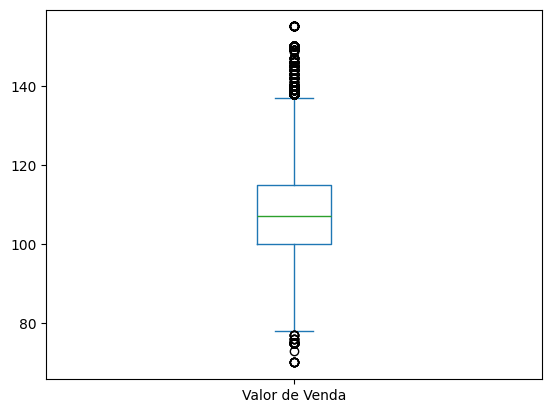

In [39]:
df1['Valor de Venda'].plot.box()

<Axes: >

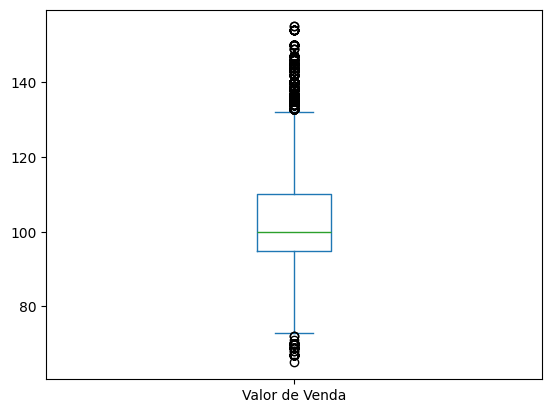

In [40]:
df2['Valor de Venda'].plot.box()

<Axes: >

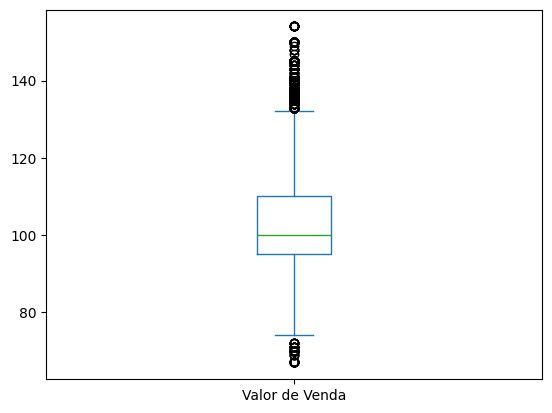

In [41]:
df3['Valor de Venda'].plot.box()

<Axes: >

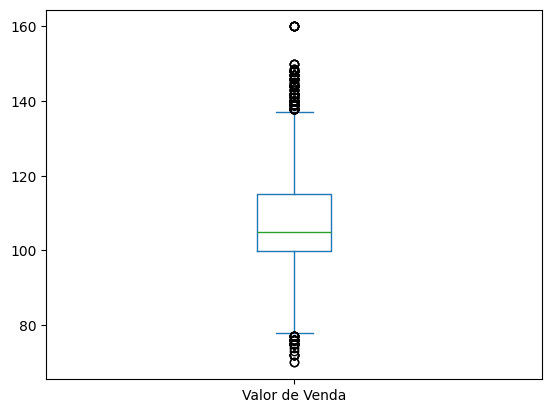

In [42]:
df4['Valor de Venda'].plot.box()

<Axes: >

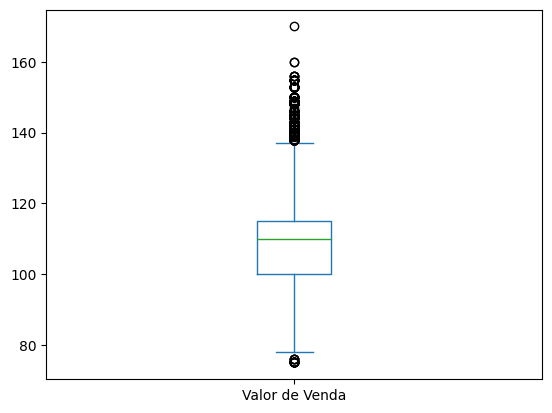

In [43]:
df5['Valor de Venda'].plot.box()

<Axes: >

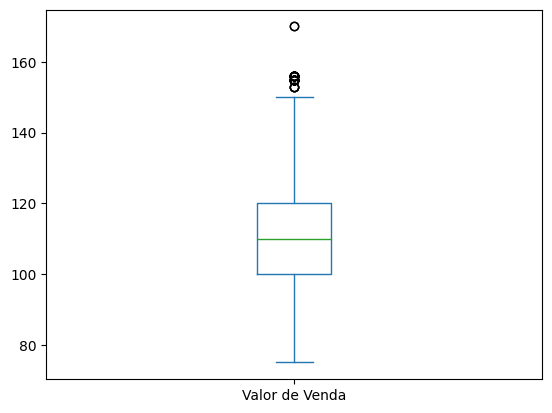

In [44]:
df6['Valor de Venda'].plot.box()

Resultado: As medidas resumo da variável 'Valor de Venda' se mantém dentro de um intervalo plausível

### 5. Coluna produto

In [45]:
produtos = []
for df in frames:
    produtos.append(df['Produto'].value_counts())

produtos

[Produto
 GLP    105341
 Name: count, dtype: int64[pyarrow],
 Produto
 GLP    121725
 Name: count, dtype: int64[pyarrow],
 Produto
 GLP    122071
 Name: count, dtype: int64[pyarrow],
 Produto
 GLP    38425
 Name: count, dtype: int64[pyarrow],
 Produto
 GLP    71780
 Name: count, dtype: int64[pyarrow],
 Produto
 GLP    53423
 Name: count, dtype: int64[pyarrow]]

Resultado: Todos os arquivos possuem apenas um tipo de produto: GLP

## 6. Coluna CNPJ

In [46]:
df1['CNPJ da Revenda'].head()

0     61.602.199/0024-09
1     19.791.896/0086-91
2     19.791.896/0020-65
3     19.791.896/0070-24
4     00.198.451/0001-85
Name: CNPJ da Revenda, dtype: string

In [47]:
df2['CNPJ da Revenda'].head()

0     61.602.199/0024-09
1     61.602.199/0065-87
2     19.791.896/0086-91
3     19.791.896/0020-65
4     19.791.896/0070-24
Name: CNPJ da Revenda, dtype: string

In [48]:
df3['CNPJ da Revenda'].head()

0     81.352.882/0002-37
1     96.265.921/0001-55
2     62.122.908/0001-25
3     59.790.436/0001-74
4     02.273.616/0001-61
Name: CNPJ da Revenda, dtype: string

In [49]:
df4['CNPJ da Revenda'].head()

0     08.220.930/0001-62
1     06.003.183/0001-85
2     00.529.581/0001-53
3     00.524.999/0001-78
4     01.198.443/0002-82
Name: CNPJ da Revenda, dtype: string

In [50]:
df5['CNPJ da Revenda'].head()

0     02.831.138/0001-68
1     06.276.865/0001-61
2     59.790.436/0001-74
3     63.957.708/0001-55
4     01.998.829/0001-98
Name: CNPJ da Revenda, dtype: string

In [51]:
df6['CNPJ da Revenda'].head()

0     2977286000195
1     6266344000395
2    35298330000602
3    12689295000215
4     2745235000138
Name: CNPJ da Revenda, dtype: string

Resultado: A coluna CNPJ do dataset 6 está na forma errada. Corrigindo:

In [52]:
df["CNPJ da Revenda"] = (
    df["CNPJ da Revenda"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # remove não numéricos
    .str.zfill(14)                       # garante 14 dígitos
    .str.replace(
        r"(\d{2})(\d{3})(\d{3})(\d{4})(\d{2})",
        r"\1.\2.\3/\4-\5",
        regex=True
    )
).astype('string[pyarrow]')

df6['CNPJ da Revenda'].head()

0    02.977.286/0001-95
1    06.266.344/0003-95
2    35.298.330/0006-02
3    12.689.295/0002-15
4    02.745.235/0001-38
Name: CNPJ da Revenda, dtype: string

#### 7. Checando tamanho dos valores das colunas

## Juntando todos os arquivos em um único 

In [53]:
final = pd.concat([df1,df2,df3,df4,df5,df6])

### Checando arquivo final

In [54]:
# valores nulos por coluna
print(final.isnull().sum())

Regiao - Sigla            0
Estado - Sigla            0
Municipio                 0
Revenda                   0
CNPJ da Revenda           0
Nome da Rua               0
Numero Rua                0
Complemento          382857
Bairro                   68
Cep                       0
Produto                   0
Data da Coleta            0
Valor de Venda            0
Unidade de Medida         0
Bandeira                  0
dtype: int64


In [55]:
# duplicatas
print(final.duplicated().sum())

0


In [56]:
# tipos de dados
print(final.dtypes)

Regiao - Sigla               string
Estado - Sigla               string
Municipio                    string
Revenda                      string
CNPJ da Revenda              string
Nome da Rua                  string
Numero Rua                   string
Complemento                  string
Bairro                       string
Cep                          string
Produto                      string
Data da Coleta       datetime64[us]
Valor de Venda              float64
Unidade de Medida            string
Bandeira                     string
dtype: object


In [57]:
# valores fora do intervalo esperado?
print(final['Valor de Venda'].describe())

count    512765.000000
mean        105.724124
std          12.679306
min          65.000000
25%          97.000000
50%         105.000000
75%         115.000000
max         170.000000
Name: Valor de Venda, dtype: float64


In [58]:
# valores únicos em colunas categóricas
print(final['Produto'].unique())
print(final['Bandeira'].unique())

<ArrowStringArray>
['GLP']
Length: 1, dtype: string
<ArrowStringArray>
[            'ULTRAGAZ', 'SUPERGASBRAS ENERGIA',  'NACIONAL GÁS BUTANO',
              'BAHIANA',             'LIQUIGÁS',               'BRANCA',
             'MINASGAS',                'FOGAS',         'COPA ENERGIA',
             'CONSIGAZ',    'NGC DISTRIBUIDORA',            'AMAZONGÁS',
              'SERVGÁS',         'SUPERGASBRAS']
Length: 14, dtype: string


In [59]:
# comprimento máximo
print(final['Complemento'].str.len().max())

# Remover espaços extras 
final['Complemento'] = final['Complemento'].str.strip().str.replace(r'\s+', ' ', regex=True)

101


In [60]:
# valores únicos 
print(final['Estado - Sigla'].unique())

<ArrowStringArray>
['MS', 'RS', 'MG', 'CE', 'BA', 'DF', 'ES', 'MA', 'PA', 'PB', 'PE', 'PI', 'RO',
 'RR', 'SC', 'SE', 'SP', 'GO', 'MT', 'PR', 'RN', 'AL', 'RJ', 'AM', 'AP', 'TO',
 'AC']
Length: 27, dtype: string


Resultado: Tudo parece ok, salvando dataset final:

In [61]:
final.to_parquet('../data/final/glp-consolidado.parquet')